## Install the dependencies



In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install scikit-learn nltk

In [2]:
!pip install openai
!pip install -q git+https://github.com/huggingface/peft.git transformers bitsandbytes datasets


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 9.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 41.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194

## Grasp point dependencies

In [3]:
!nvidia-smi
%pip install ultralytics
import ultralytics
ultralytics.checks()
import os
HOME = os.getcwd()
print("HOME:", HOME)
%pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'
%pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights
CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))
import torch
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

Ultralytics YOLOv8.2.50 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 30.9/78.2 GB disk)
HOME: /content
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.8/367.8 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.2/76.2 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.0/124.0 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.6 MB/s eta 0:00:00
/content/weights/sam_vit_h_4b8939.pth ; exist: True


In [4]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
from ultralytics import YOLO
import numpy as np
import cv2 as cv
import random
from math import atan2, cos, sin, sqrt, pi , tan , radians
from shapely.geometry import LineString,Polygon
from google.colab.patches import cv2_imshow
from itertools import combinations
import supervision as sv
from PIL import Image

## Run the few_shot_instruction_generation.py and fine_tuned_blip_inference.py scripts

In [12]:
%run few_shot_instruction_generation.py #add the api key in the script then run
%run fine_tuned_blip_inference.py

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

##Grasp Point Genration model


In [30]:
desired_label=["remote","bottle","cup","bowl","vase","scissors","toothbrush","wine glass"]
def process_image(IMAGE_PATH,desired_label):
  model = YOLO("yolov8n.pt")
  results = model([IMAGE_PATH],verbose=False)
  for result in results:
    boxes = result.boxes
    if(boxes.shape[0]==0):
      return [0,0,0,0]
    for i in range(boxes.shape[0]):
        if (model.names[int(boxes.cls[i].item())] in desired_label):
          bounding_box=np.array([(boxes.xyxy[i].cpu().numpy()[0]),
                        (boxes.xyxy[i].cpu().numpy()[1]),
                        (boxes.xyxy[i].cpu().numpy()[2]),
                        (boxes.xyxy[i].cpu().numpy()[3])])

          return bounding_box
        else:
          return [0,0,0,0]

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam)
mask_predictor = SamPredictor(sam)
def sam_segment(bbox,IMAGE_PATH):
  image_bgr = cv.imread(IMAGE_PATH)
  image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
  mask_predictor.set_image(image_rgb)

  masks, scores, logits = mask_predictor.predict(
      box=bbox,
      multimask_output=False,
  )
  detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
  )
  detections = detections[detections.area == np.max(detections.area)]
  return detections
def calculate_angle_and_coordinates(ann,image,bbox):
      images=[]
      bw=ann.mask[0].astype(int)
      bw = np.array(bw, np.uint8)
      contours, _ = cv.findContours(bw, cv.RETR_LIST, cv.CHAIN_APPROX_NONE)
      points=[]
      max_area=0
      for k, c in enumerate(contours):
        area = cv.contourArea(c)
        if max_area<area:
          rect = cv.minAreaRect(c)
          box = cv.boxPoints(rect)
          box = np.int0(box)
          width = int(rect[1][0])
          height = int(rect[1][1])
          angle = int(rect[2])
          if np.sqrt(pow(box[0][0]-box[0][1],2)+pow(box[0][1]-box[1][1],2))<np.sqrt(pow(box[2][0]-box[3][0],2)+pow(box[2][1]-box[3][1],2)):
              angle = 90+angle
          else:
              angle=-angle
          x=random.randint(int(bbox[0]),int(bbox[2]))
          y=random.randint(int(bbox[1]),int(bbox[3]))
          x_limit=list(range(x-1024,x+1024))
          x_limit=np.array(x_limit)
          y_limit=[]
          if (angle != 90 or angle!=-90):
              for k in range(-1024,1024):
                  y_limit.append(y-tan( radians(angle))*k)
          else:
              for k in range(-1024,1024):
                  y_limit.append(y)
          max_area=area
      for k, c in enumerate(contours):
        c=np.reshape(c,(-1,2))
        line_1=LineString(np.column_stack((x_limit,y_limit)))
        if(len(c)<4):
          return None
        line_2=Polygon(c)
        intersection=line_1.intersection(line_2,grid_size=1)
        if type(intersection) is LineString:
          if intersection:
            points.append([intersection.xy[0][0],intersection.xy[1][0]])
            points.append([intersection.xy[0][-1],intersection.xy[1][-1]])
      points.sort()
      if points:
        image_copy=image.copy()
        cv.circle(image_copy,(int(points[0][0]),int(points[0][1])),25,(0,255,0),-1)
        cv.circle(image_copy,(int(points[1][0]),int(points[1][1])),25,(0,255,0),-1)
        images.append(image_copy)
      if (len(points)>2):
        image_copy=image.copy()
        cv.circle(image_copy,(int(points[-1][0]),int(points[-1][1])),25,(0,255,0),-1)
        cv.circle(image_copy,(int(points[-2][0]),int(points[-2][1])),25,(0,255,0),-1)
        images.append(image_copy)
      return images

def grasp_point_gen(image_path,output_folder):
  count=0
  image_bgr = cv.imread(image_path)
  image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)
  bbox=process_image(image_path,desired_label)
  if(type(bbox)!=list):
    detections=sam_segment(bbox,image_path)
    while(True):
      if count<30:
        image = calculate_angle_and_coordinates(detections,image_rgb,bbox)
        if(image is not None):
          for j in range(len(image)):
            name = f'{count}.jpg'
            output_path = os.path.join(output_folder, name)
            cv.imwrite(output_path, image[j])
            count=count+1
      else:
        break

In [52]:
def generate_images(output_path,image_path):
  grasp_point_gen(image_path,output_path)
  grasp_points=[]
  for filename in os.listdir(output_path):
      image_path = os.path.join(output_path, filename)
      grasp_points.append(image_path)
  return grasp_points

## Use a language model to calculate the cosine similraity and filter the grasp points



In [22]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
scoring_model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    with torch.no_grad():
        outputs = scoring_model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.numpy()


## Find the best grasp score

In [44]:
import os

def delete_files_in_directory(directory_path):
   try:
     files = os.listdir(directory_path)
     for file in files:
       file_path = os.path.join(directory_path, file)
       if os.path.isfile(file_path):
         os.remove(file_path)
     print("All files deleted successfully.")
   except OSError:
     print("Error occurred while deleting files.")

In [59]:
def best_grasp_point(input_image_path,out_put_path,user_input):
  delete_files_in_directory(out_put_path,)
  print("User prompt:\n",user_input)
  print("User input picture:")
  cv2_imshow(cv2.imread(input_image_path))
  #get the instructions
  input_caption = generate_caption(Image.open(input_image_path),base_model)
  print("Input Image Caption:")
  print(input_caption)
  instructions = generate_instruction(user_input,input_caption)
  print("Generated instructions:")
  print(instructions)
  #extract the grasping location from the instructions

  parts = instructions.split("grasping location:")

  task_details = parts[0].strip()

  grasping_location = "grasping location a " + parts[1].strip()

  #get the grasp points

  grasp_points=generate_images(output_path,image_path)

  #find the best grasp point
  grasp_scores = []
  for image_p in grasp_points:
    image=Image.open(image_p)
    caption = generate_caption(image,fine_tuned_model)
    # Get embeddings for the caption and the grasping location
    caption_embedding = get_embedding(caption)
    grasping_location_embedding = get_embedding(grasping_location)

    # Calculate cosine similarity
    cosine_sim = cosine_similarity(caption_embedding, grasping_location_embedding)
    grasp_scores.append([image_p,caption, cosine_sim[0][0]])


  highest_score_item = max(grasp_scores, key=lambda x: x[1])

  #return the best grasping location
  print("Best Grasp Point: ")
  print(highest_score_item[1])
  print("Cosine Similarity: ",highest_score_item[2])
  return highest_score_item




All files deleted successfully.
User prompt:
 i want to cut a paper
User input picture:


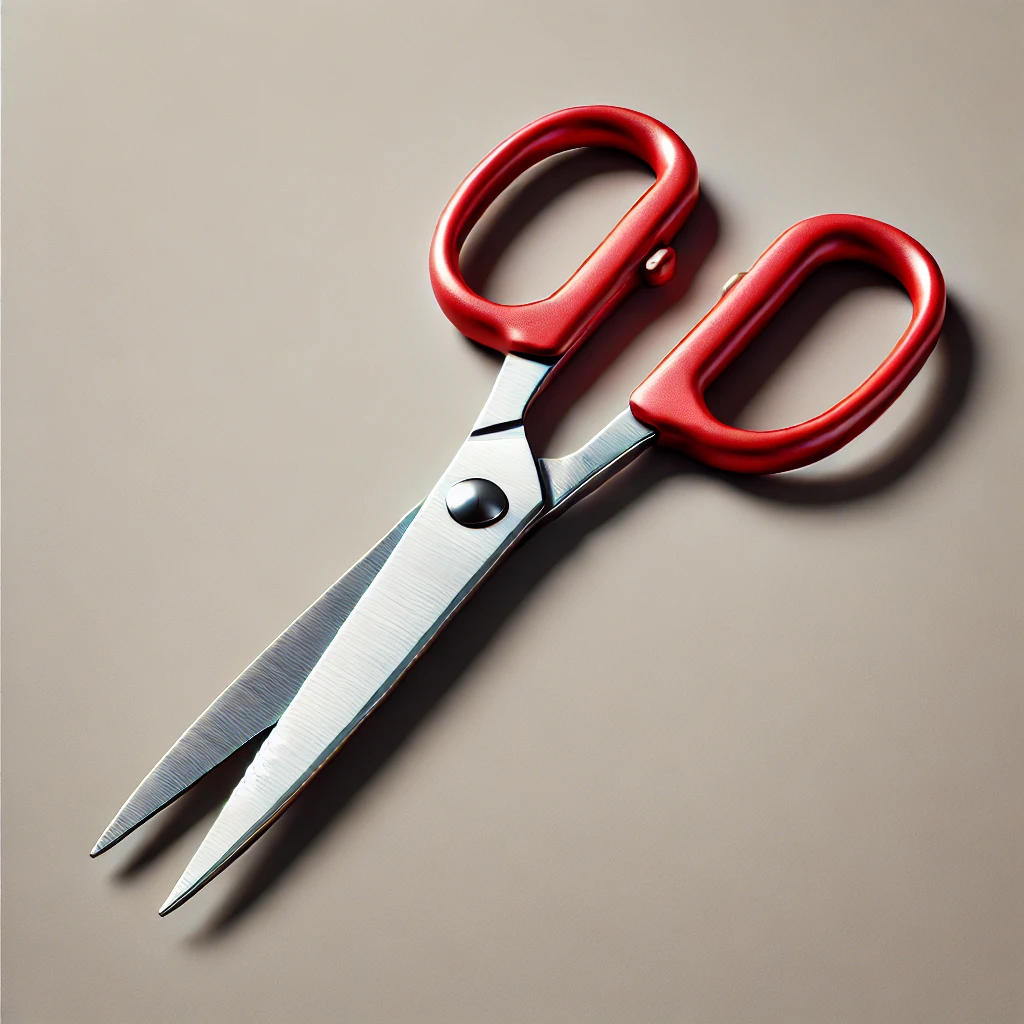

Input Image Caption:
a close up of a pair of red scissors on a table
Generated instructions:
task: pick up the scissors and cut the paper
object: scissors
grasping location: scissors' handles
Best Grasp Point: 
grasping location a scissors's handle
Cosine Similarity:  0.9707061


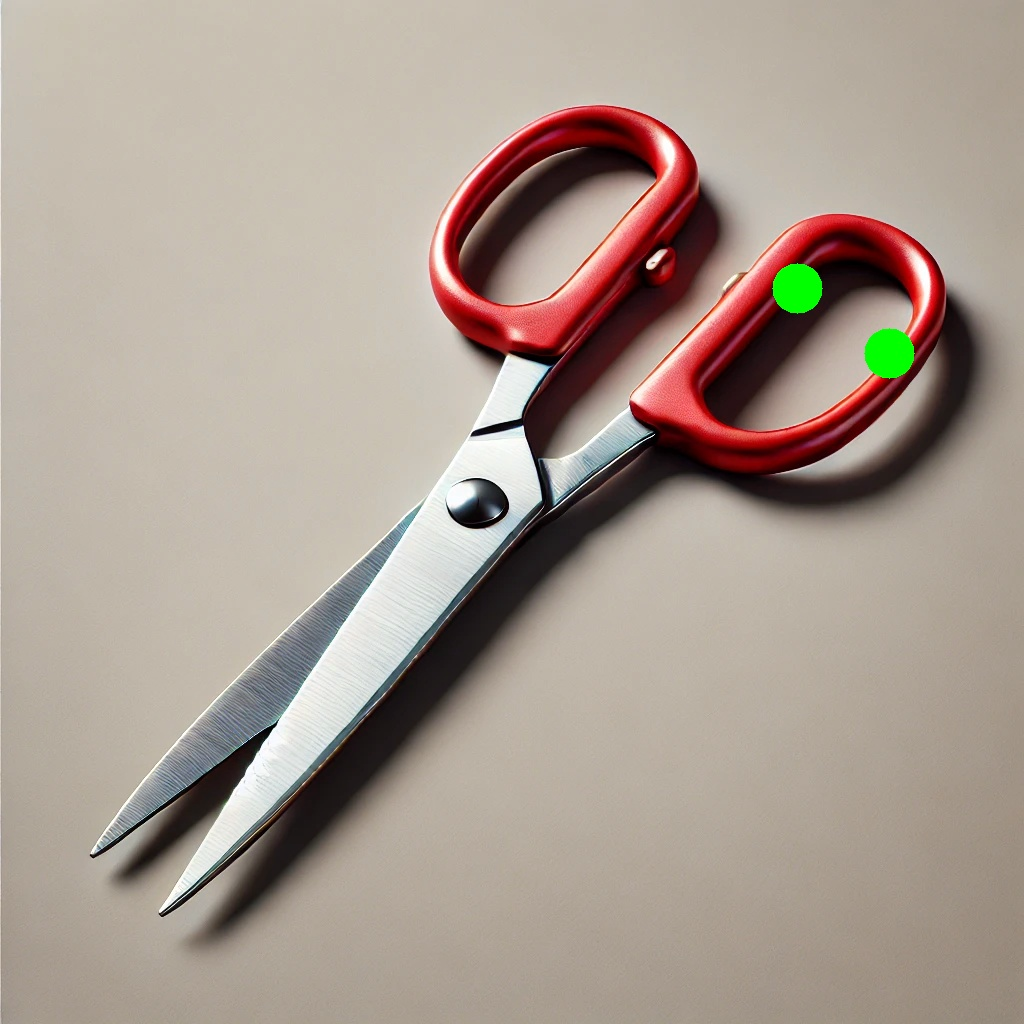

In [64]:
import warnings
import cv2
from google.colab.patches import cv2_imshow
warnings.filterwarnings("ignore")
output_path="/content/drive/MyDrive/LLM final project/test output"
image_path = "/content/drive/MyDrive/LLM final project/test/gheichi.jpg"
user_input = "i want to cut a paper"

best = best_grasp_point(image_path,output_path,user_input)
cv2_imshow(cv2.cvtColor(cv2.imread(best[0]), cv2.COLOR_BGR2RGB))